# Data Transformations — Wage Analysis
**Milestone 2 | Understanding the Data**

This notebook covers the transformations applied to the Occupational Employment & Wage dataset:
- Normalization (Min-Max Scaling)
- Standardization (Z-Score / Standard Scaler)
- Log Transformation
- Dimensionality Reduction (PCA)

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Cleaned Dataset

In [2]:
DATA_PATH = 'https://media.githubusercontent.com/media/Soorej30/wage_analysis/main/cleaned_data/combined_data_by_year.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (739544, 24)


,AREA,ST,STATE,OCC_CODE,OCC_TITLE,GROUP,TOT_EMP,EMP_PRSE,MEAN_PRSE,H_MEAN,...,H_PCT90,A_MEAN,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,year
0,1,AL,Alabama,11-0000,Management occupations,major,75100.0,1.0,0.6,44.06,...,77.24,91650.0,40540.0,56100.0,78870.0,112190.0,160660.0,NaN,NaN,2009
1,1,AL,Alabama,11-1011,Chief executives,NaN,2960.0,3.5,2.2,79.98,...,NaN,166350.0,70060.0,105360.0,160830.0,NaN,NaN,NaN,NaN,2009
2,1,AL,Alabama,11-1021,General and operations managers,NaN,33390.0,1.4,0.9,46.09,...,NaN,95880.0,42470.0,56280.0,79090.0,117360.0,NaN,NaN,NaN,2009
3,1,AL,Alabama,11-1031,Legislators,NaN,1350.0,5.1,2.2,NaN,...,NaN,18840.0,14090.0,14720.0,15780.0,18590.0,26680.0,True,NaN,2009
4,1,AL,Alabama,11-2011,Advertising and promotions managers,NaN,160.0,14.5,7.3,39.45,...,61.82,82060.0,41170.0,55190.0,66250.0,90730.0,128590.0,NaN,NaN,2009


In [3]:
df.dtypes

AREA          int64
ST              str
STATE           str
OCC_CODE        str
OCC_TITLE       str
GROUP           str
TOT_EMP      object
EMP_PRSE     object
MEAN_PRSE    object
H_MEAN       object
H_PCT10      object
H_PCT25      object
H_MEDIAN     object
H_PCT75      object
H_PCT90      object
A_MEAN       object
A_PCT10      object
A_PCT25      object
A_MEDIAN     object
A_PCT75      object
A_PCT90      object
ANNUAL       object
HOURLY       object
year          int64
dtype: object

## 3. Fix Column Types

Several wage/employment columns are loaded as `object` (string) due to special values like `'*'` or `'#'` used by the BLS to suppress or flag data. We convert them to numeric, turning those flags into `NaN`.

In [4]:
numeric_cols = ['TOT_EMP', 'EMP_PRSE', 'MEAN_PRSE',
                'H_MEAN', 'A_MEAN',
                'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90',
                'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Dtypes after conversion:')
print(df[numeric_cols].dtypes)
print(f'\nMissing values per column:')
print(df[numeric_cols].isnull().sum())

Dtypes after conversion:
TOT_EMP      float64
EMP_PRSE     float64
MEAN_PRSE    float64
H_MEAN       float64
A_MEAN       float64
H_PCT10      float64
H_PCT25      float64
H_MEDIAN     float64
H_PCT75      float64
H_PCT90      float64
A_PCT10      float64
A_PCT25      float64
A_MEDIAN     float64
A_PCT75      float64
A_PCT90      float64
dtype: object

Missing values per column:
TOT_EMP      27461
EMP_PRSE     27461
MEAN_PRSE     8856
H_MEAN       58643
A_MEAN       11485
H_PCT10      58730
H_PCT25      60790
H_MEDIAN     65254
H_PCT75      70700
H_PCT90      82075
A_PCT10      11572
A_PCT25      13632
A_MEDIAN     18158
A_PCT75      23899
A_PCT90      36878
dtype: int64


## 4. Select Wage Features for Transformation

In [5]:
wage_cols = ['TOT_EMP', 'A_MEAN', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90']

df_num = df[wage_cols].copy()
df_num_clean = df_num.dropna()

print(f'Full shape: {df_num.shape}  |  After dropping NaN: {df_num_clean.shape}')
df_num_clean.describe().round(2)

Full shape: (739544, 7)  |  After dropping NaN: (677021, 7)


,TOT_EMP,A_MEAN,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90
count,677021.00,677021.00,677021.00,677021.00,677021.00,677021.00,677021.00
mean,7858.18,50669.74,31351.97,38200.13,47891.93,60148.02,74152.17
std,43310.91,23432.14,13983.15,17623.49,22510.93,28690.23,36656.06
min,30.00,12160.00,11140.00,11650.00,12490.00,13330.00,13840.00
25%,250.00,33130.00,20760.00,25080.00,30990.00,38410.00,47080.00
50%,820.00,45270.00,28180.00,34360.00,42960.00,53650.00,64470.00
75%,3100.00,63280.00,38130.00,47340.00,60120.00,76080.00,93990.00
max,2718950.00,223200.00,203290.00,211420.00,221710.00,234090.00,239130.00


## 5. Min-Max Normalization

Scales every feature to the range [0, 1].

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

When to use: When we need values on a bounded scale (e.g., for neural networks or distance-based models).

In [6]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df_num_clean),
    columns=[f'{c}_minmax' for c in df_num_clean.columns]
)

print('Min-Max Normalized — descriptive stats (all values should be in [0, 1]):')
df_minmax.describe().round(4)

Min-Max Normalized — descriptive stats (all values should be in [0, 1]):


,TOT_EMP_minmax,A_MEAN_minmax,A_PCT10_minmax,A_PCT25_minmax,A_MEDIAN_minmax,A_PCT75_minmax,A_PCT90_minmax
count,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000
mean,0.0029,0.1825,0.1052,0.1329,0.1692,0.2121,0.2677
std,0.0159,0.1110,0.0728,0.0882,0.1076,0.1300,0.1627
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0001,0.0994,0.0501,0.0672,0.0884,0.1136,0.1475
50%,0.0003,0.1569,0.0887,0.1137,0.1456,0.1826,0.2247
75%,0.0011,0.2422,0.1405,0.1787,0.2277,0.2842,0.3558
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


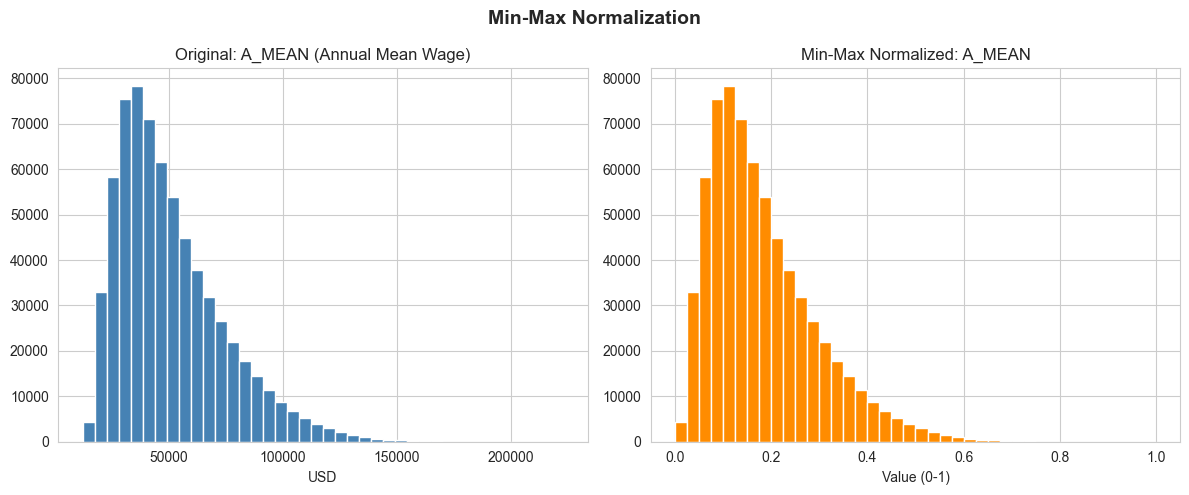

<Figure size 1200x500 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df_num_clean['A_MEAN'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Original: A_MEAN (Annual Mean Wage)')
axes[0].set_xlabel('USD')

axes[1].hist(df_minmax['A_MEAN_minmax'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Min-Max Normalized: A_MEAN')
axes[1].set_xlabel('Value (0-1)')

plt.suptitle('Min-Max Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Standardization (Z-Score)

Centers data to mean = 0 and scales to std = 1.

$$x' = \frac{x - \mu}{\sigma}$$

When to use: When features have different units/scales and the model assumes a normal distribution (e.g., linear regression, SVM, PCA).

In [26]:
scaler_std = StandardScaler()
df_standardized = pd.DataFrame(
    scaler_std.fit_transform(df_num_clean),
    columns=[f'{c}_std' for c in df_num_clean.columns]
)

print('Standardized — descriptive stats (mean ~ 0, std ~ 1):')
df_standardized.describe().round(4)

Standardized — descriptive stats (mean ~ 0, std ~ 1):


,TOT_EMP_std,A_MEAN_std,A_PCT10_std,A_PCT25_std,A_MEDIAN_std,A_PCT75_std,A_PCT90_std
count,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000,677021.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.1807,-1.6435,-1.4455,-1.5065,-1.5727,-1.6318,-1.6454
25%,-0.1757,-0.7485,-0.7575,-0.7445,-0.7508,-0.7577,-0.7385
50%,-0.1625,-0.2304,-0.2268,-0.2179,-0.2191,-0.2265,-0.2641
75%,-0.1099,0.5382,0.4847,0.5186,0.5432,0.5553,0.5412
max,62.5961,7.3630,12.2961,9.8289,7.7215,6.0628,4.5007


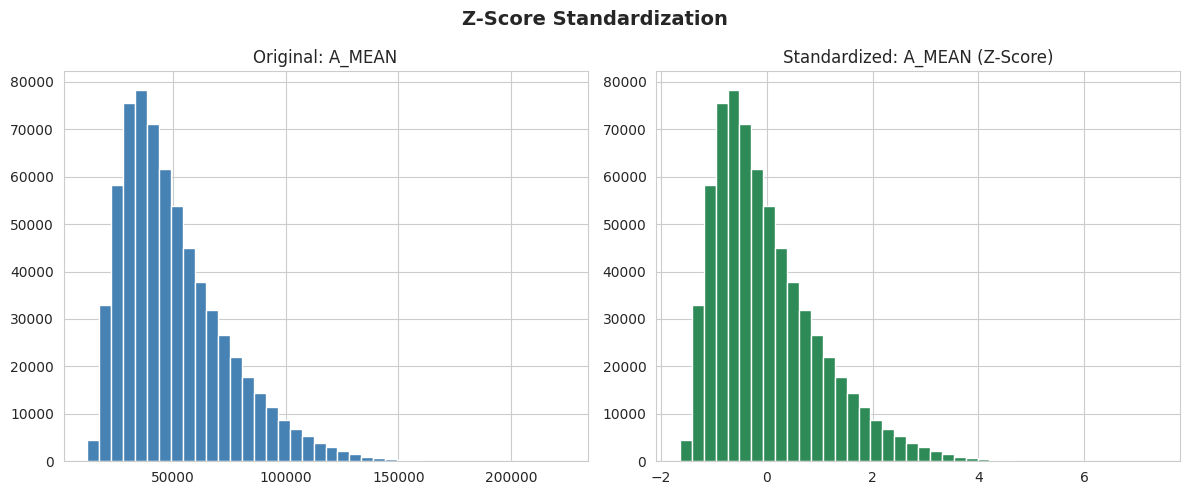

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df_num_clean['A_MEAN'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Original: A_MEAN')

axes[1].hist(df_standardized['A_MEAN_std'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Standardized: A_MEAN (Z-Score)')

plt.suptitle('Z-Score Standardization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Log Transformation

Reduces right skew (very common in wage/income data) by compressing large values.

$$x' = \log(x + 1)$$

*(+1 avoids log(0) errors for zero-valued entries)*

When to use: When data is heavily right-skewed (e.g., salary, total employment counts).

In [28]:
df_log = np.log1p(df_num_clean.clip(lower=0))
df_log.columns = [f'{c}_log' for c in df_num_clean.columns]

skew_original = df_num_clean.skew().rename('Original Skewness')
skew_log = df_log.skew()
skew_log.index = df_num_clean.columns
skew_log = skew_log.rename('Log-Transformed Skewness')

print('Skewness Comparison (closer to 0 = more symmetric):')
pd.concat([skew_original, skew_log], axis=1).round(3)

Skewness Comparison (closer to 0 = more symmetric):


,Original Skewness,Log-Transformed Skewness
TOT_EMP,20.305,0.517
A_MEAN,1.115,0.083
A_PCT10,1.446,0.319
A_PCT25,1.306,0.186
A_MEDIAN,1.161,0.070
A_PCT75,1.085,0.007
A_PCT90,1.121,0.034


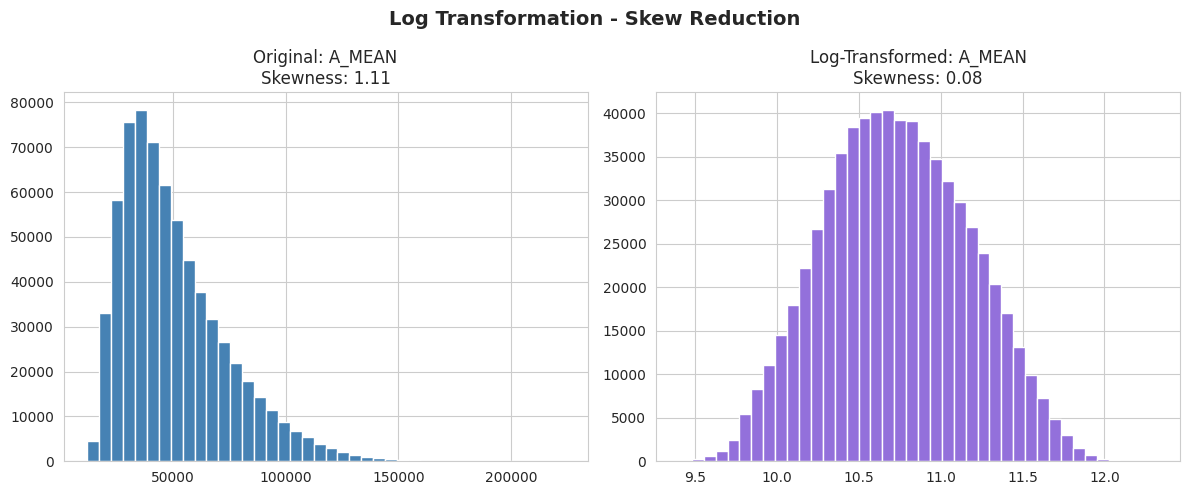

In [29]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(df_num_clean['A_MEAN'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original: A_MEAN\nSkewness: {df_num_clean["A_MEAN"].skew():.2f}')

axes[1].hist(df_log['A_MEAN_log'], bins=40, color='mediumpurple', edgecolor='white')
axes[1].set_title(f'Log-Transformed: A_MEAN\nSkewness: {df_log["A_MEAN_log"].skew():.2f}')

plt.suptitle('Log Transformation - Skew Reduction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. All Transformations Side-by-Side

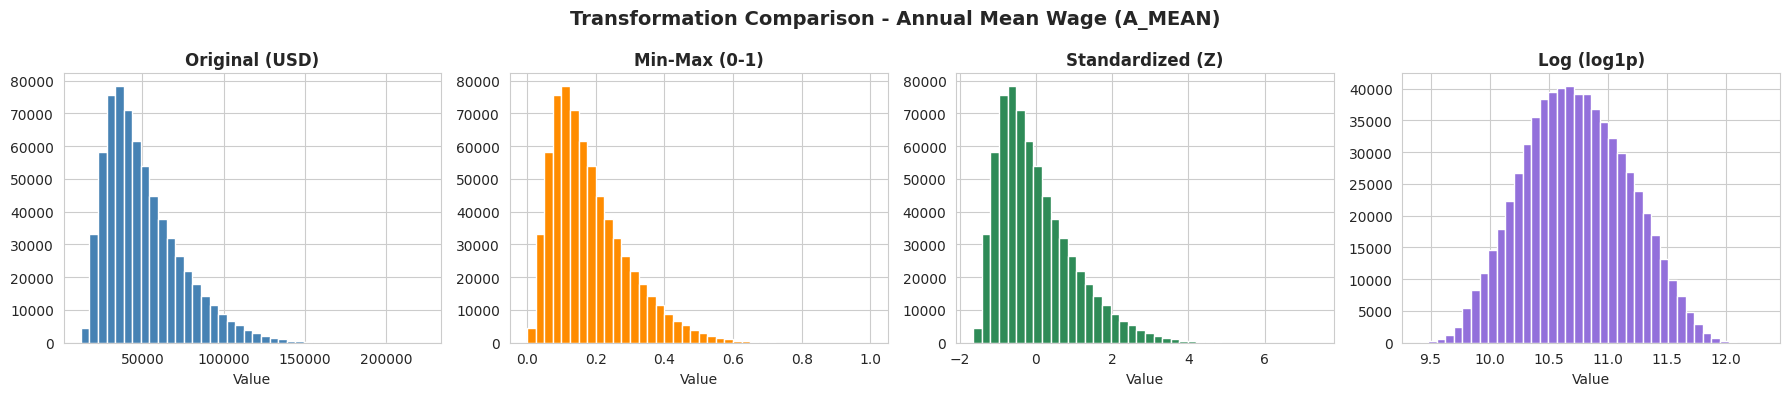

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

data_pairs = [
    (df_num_clean['A_MEAN'],        'Original (USD)',   'steelblue'),
    (df_minmax['A_MEAN_minmax'],    'Min-Max (0-1)',    'darkorange'),
    (df_standardized['A_MEAN_std'], 'Standardized (Z)', 'seagreen'),
    (df_log['A_MEAN_log'],          'Log (log1p)',      'mediumpurple'),
]

for ax, (data, title, color) in zip(axes, data_pairs):
    ax.hist(data.dropna(), bins=40, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')

plt.suptitle('Transformation Comparison - Annual Mean Wage (A_MEAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Dimensionality Reduction — PCA

Principal Component Analysis (PCA) reduces the number of features while retaining as much variance as possible. Useful before applying ML models.

**Steps:**
1. Standardize the data (PCA is sensitive to scale)
2. Fit PCA and inspect explained variance
3. Choose the optimal number of components
4. Inspect feature loadings

In [31]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df_num_clean)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f'Total features: {X_scaled.shape[1]}')
print(f'Components to explain 90% variance: {np.argmax(cumulative_variance >= 0.90) + 1}')
print(f'Components to explain 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}')

Total features: 7
Components to explain 90% variance: 2
Components to explain 95% variance: 2


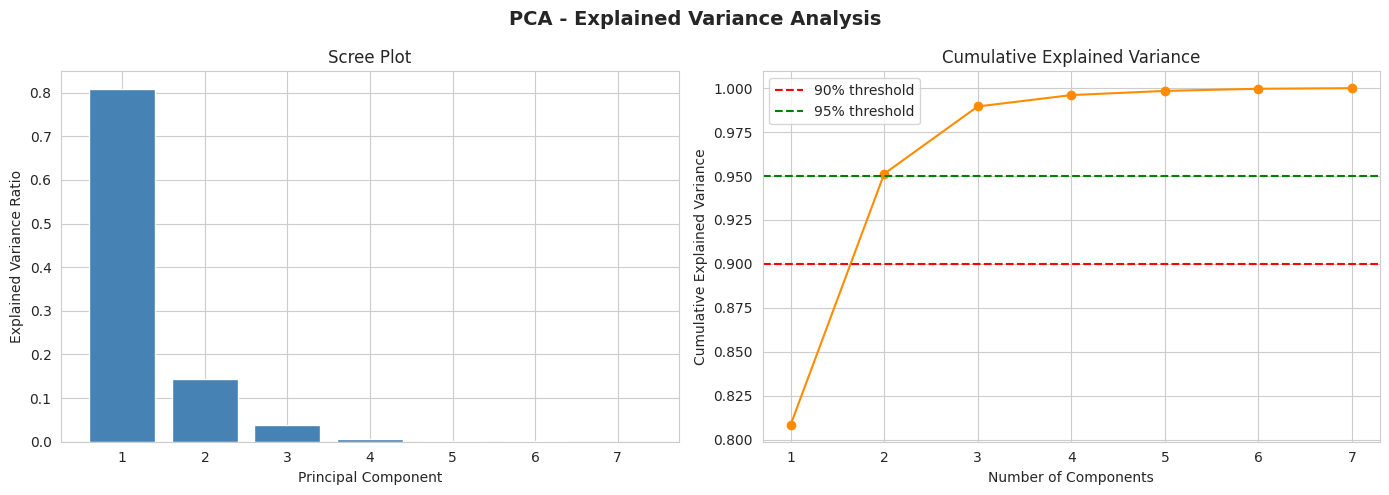

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained_variance)+1), explained_variance, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', color='darkorange')
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(0.95, color='green', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA - Explained Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
n_components = int(np.argmax(cumulative_variance >= 0.95) + 1)
print(f'Using {n_components} principal components (>= 95% variance retained)')

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
print(f'Reduced dataset shape: {df_pca.shape}')
df_pca.head()

Using 2 principal components (>= 95% variance retained)
Reduced dataset shape: (677021, 2)


,PC1,PC2
0,3.634846,1.699413
1,-3.303646,-0.219981
2,2.605577,-0.091466
3,4.993854,-0.041897
4,4.036688,0.036571


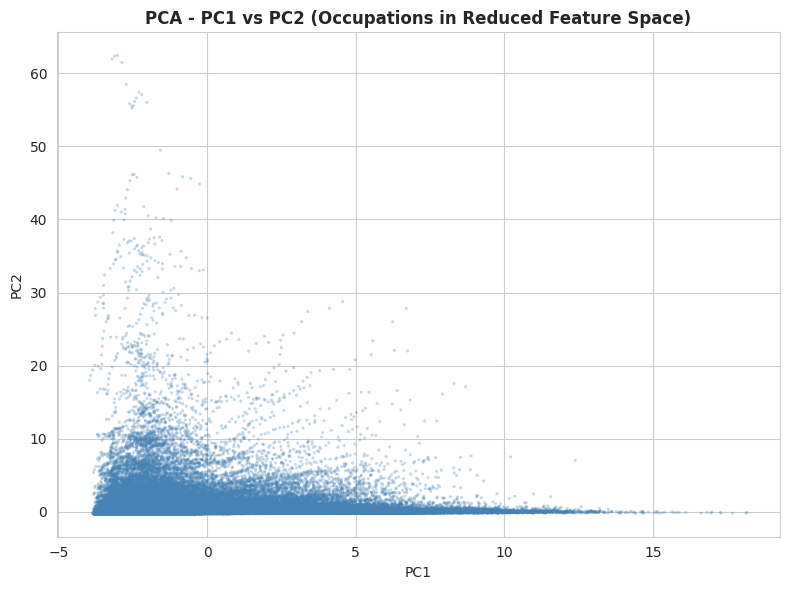

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.3, color='steelblue', edgecolors='none', s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - PC1 vs PC2 (Occupations in Reduced Feature Space)', fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_num_clean.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)
print('Feature Loadings (contribution of each original feature to each PC):')
loadings.round(3)

Feature Loadings (contribution of each original feature to each PC):


,PC1,PC2
TOT_EMP,-0.020,0.998
A_MEAN,0.419,0.020
A_PCT10,0.393,-0.023
A_PCT25,0.410,-0.014
A_MEDIAN,0.416,0.002
A_PCT75,0.413,0.022
A_PCT90,0.398,0.043


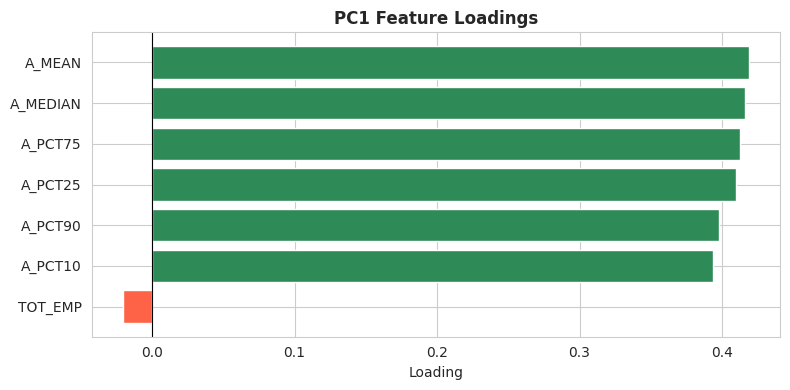

In [36]:
pc1_loadings = loadings['PC1'].sort_values(ascending=True)

plt.figure(figsize=(8, 4))
colors = ['seagreen' if v > 0 else 'tomato' for v in pc1_loadings]
plt.barh(pc1_loadings.index, pc1_loadings.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Loading')
plt.title('PC1 Feature Loadings', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Summary
Key findings:
- `A_MEAN`, `A_MEDIAN`, and `TOT_EMP` show significant right skew — log transformation improves symmetry.
- Standardization is applied before PCA since PCA is scale-sensitive.
- PCA retains >= 95% of variance with fewer components than the original 7 features, reducing redundancy among the highly correlated wage percentile columns.